<a href="https://colab.research.google.com/github/jceltruda/Projects-in-AI-and-ML/blob/main/Project_5/ML_AI_Projects_5_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1

**Dataset Selection:** I selected the "Bone Break Classification Image Dataset" from Kaggle. Link: [pkdarabi/bone-break-classification-image-dataset](https://www.kaggle.com/datasets/pkdarabi/bone-break-classification-image-dataset)

In [ ]:
!pip install kagglehub

import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Download latest version of the dataset
dataset_path = kagglehub.dataset_download("pkdarabi/bone-break-classification-image-dataset")
print("Path to dataset files:", dataset_path)
data_dir = os.path.join(dataset_path, 'Bone Break Classification/Bone Break Classification')

Using device: cuda
Using Colab cache for faster access to the 'bone-break-classification-image-dataset' dataset.
Path to dataset files: /kaggle/input/bone-break-classification-image-dataset


## Part 1

Classes found: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']


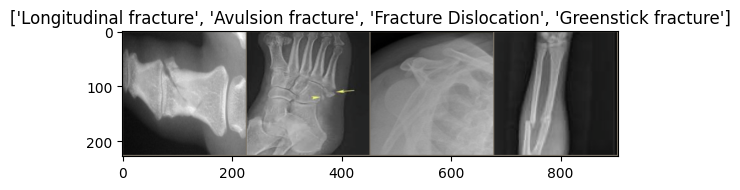

In [ ]:
# Standard Base Transforms
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load Dataset
full_dataset = datasets.ImageFolder(root=data_dir, transform=base_transform)
classes = full_dataset.classes
print(f"Classes found: {classes}")

# Split into Train and Validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Visualization Function
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Visualize a batch of training data
inputs, classes_batch = next(iter(train_loader))
out = torchvision.utils.make_grid(inputs[:4])
imshow(out, title=[classes[x] for x in classes_batch[:4]])

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=len(classes)):
        super(CustomCNN, self).__init__()
        # Conv Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        # Conv Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        # Conv Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)

        # Classifier
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = x.view(x.size(0), -1) # Flatten
        x = self.relu4(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Training function
def train_and_evaluate(model, train_loader, val_loader, epochs=15):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = 100 * correct / total
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Val Accuracy: {epoch_acc:.2f}%")

    return epoch_acc

# Initialize and train CNN
print("Training:")
custom_model = CustomCNN().to(device)
custom_acc = train_and_evaluate(custom_model, train_loader, val_loader, epochs=15)

Training:
Epoch 1/15 | Loss: 2.8367 | Val Accuracy: 14.16%
Epoch 2/15 | Loss: 2.2457 | Val Accuracy: 16.37%
Epoch 3/15 | Loss: 2.1360 | Val Accuracy: 18.58%
Epoch 4/15 | Loss: 1.9783 | Val Accuracy: 23.45%
Epoch 5/15 | Loss: 1.6700 | Val Accuracy: 26.99%
Epoch 6/15 | Loss: 1.3191 | Val Accuracy: 27.43%
Epoch 7/15 | Loss: 0.9062 | Val Accuracy: 25.66%
Epoch 8/15 | Loss: 0.5933 | Val Accuracy: 32.74%
Epoch 9/15 | Loss: 0.3147 | Val Accuracy: 33.63%
Epoch 10/15 | Loss: 0.2070 | Val Accuracy: 31.42%
Epoch 11/15 | Loss: 0.1649 | Val Accuracy: 30.97%
Epoch 12/15 | Loss: 0.1227 | Val Accuracy: 34.07%
Epoch 13/15 | Loss: 0.0882 | Val Accuracy: 34.51%
Epoch 14/15 | Loss: 0.1724 | Val Accuracy: 32.74%
Epoch 15/15 | Loss: 0.0777 | Val Accuracy: 32.30%


I chose an architecture with 3 convolutional layers and then ReLU activation. I thought this would be complex enough to capture complex features in the dataset such as standard bone edges vs fractures.

To evaluate performance I used cross-entropy loss and accuracy. CE loss measures the performance of a classification model based on the probability value 0-1 it outputs, while accuracy counts total correct classifications out of the total.

## Part 2

In [ ]:
# Load pre-trained ResNet50
resnet_model = models.resnet50(pretrained=True)
for param in resnet_model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer to match our number of classes
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, len(classes))
resnet_model = resnet_model.to(device)

print("Training:")
resnet_acc = train_and_evaluate(resnet_model, train_loader, val_loader, epochs=15)

Training:
Epoch 1/15 | Loss: 2.3498 | Val Accuracy: 23.89%
Epoch 2/15 | Loss: 2.0720 | Val Accuracy: 29.20%
Epoch 3/15 | Loss: 1.9235 | Val Accuracy: 29.20%
Epoch 4/15 | Loss: 1.8705 | Val Accuracy: 31.42%
Epoch 5/15 | Loss: 1.7310 | Val Accuracy: 30.97%
Epoch 6/15 | Loss: 1.6843 | Val Accuracy: 31.86%
Epoch 7/15 | Loss: 1.5916 | Val Accuracy: 29.65%
Epoch 8/15 | Loss: 1.5423 | Val Accuracy: 30.97%
Epoch 9/15 | Loss: 1.5190 | Val Accuracy: 32.30%
Epoch 10/15 | Loss: 1.4737 | Val Accuracy: 30.53%
Epoch 11/15 | Loss: 1.4784 | Val Accuracy: 34.51%
Epoch 12/15 | Loss: 1.4011 | Val Accuracy: 32.74%
Epoch 13/15 | Loss: 1.3309 | Val Accuracy: 34.07%
Epoch 14/15 | Loss: 1.3331 | Val Accuracy: 34.96%
Epoch 15/15 | Loss: 1.3265 | Val Accuracy: 34.07%


Differences:
* The first model continued to decrease loss as training went on, potentially overfitting as accuracy fluctuated. The second converged to a stable loss around epoch 9, it dropped slowly after this while accuracy increased.

## Part 3

In [ ]:
# Define Augmented Transforms
aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20), # Rotation
    transforms.RandomHorizontalFlip(p=0.5), # Horizontal Flip
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create a new dataset instance for augmented training data
aug_train_dataset = datasets.ImageFolder(root=data_dir, transform=aug_transform)

aug_train_subset = torch.utils.data.Subset(aug_train_dataset, train_dataset.indices)

# Recreate DataLoader for augmented data
aug_train_loader = DataLoader(aug_train_subset, batch_size=32, shuffle=True)

# Train on augmented data
print("Training...")
aug_custom_model = CustomCNN().to(device)
aug_acc = train_and_evaluate(aug_custom_model, aug_train_loader, val_loader, epochs=15)

Training...
Epoch 1/15 | Loss: 2.4170 | Val Accuracy: 15.93%
Epoch 2/15 | Loss: 2.2489 | Val Accuracy: 15.93%
Epoch 3/15 | Loss: 2.2291 | Val Accuracy: 12.39%
Epoch 4/15 | Loss: 2.2208 | Val Accuracy: 18.58%
Epoch 5/15 | Loss: 2.1731 | Val Accuracy: 17.70%
Epoch 6/15 | Loss: 2.1582 | Val Accuracy: 18.14%
Epoch 7/15 | Loss: 2.1073 | Val Accuracy: 21.24%
Epoch 8/15 | Loss: 2.0433 | Val Accuracy: 21.68%
Epoch 9/15 | Loss: 2.0156 | Val Accuracy: 22.12%
Epoch 10/15 | Loss: 1.9863 | Val Accuracy: 23.89%
Epoch 11/15 | Loss: 1.9021 | Val Accuracy: 26.11%
Epoch 12/15 | Loss: 1.8891 | Val Accuracy: 26.11%
Epoch 13/15 | Loss: 1.8331 | Val Accuracy: 26.99%
Epoch 14/15 | Loss: 1.7447 | Val Accuracy: 26.55%
Epoch 15/15 | Loss: 1.6549 | Val Accuracy: 26.99%


I applied image rotation and horizontal flipping to increase the diversity of the dataset. The converged loss was higher and accuracy was lower. The model struggled to classify the dataset to begin with, the image transformations made this task even more difficult, hurting performance.